In [7]:
import os
import re
import random
import string

PASTA_BRASIL = 'PASTA_BRASIL'     
PASTA_ESPORTE = 'PASTA_ESPORTE'   

# Lista de stopwords 
stop_words = {
    'a', 'o', 'e', 'é', 'de', 'da', 'do', 'em', 'um', 'uma', 'para', 'com',
    'não', 'na', 'no', 'os', 'as', 'que', 'por', 'se', 'como', 'mais',
    'mas', 'foi', 'ao', 'à', 'das', 'dos', 'sobre', 'já', 'ou', 'também'
}

def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = re.findall(r'\b[\wáéíóúàâêôãõç]+\b', text, flags=re.UNICODE)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

def ler_textos(pasta):
    textos = []
    for nome_arquivo in os.listdir(pasta):
        if nome_arquivo.endswith('.txt'):
            caminho = os.path.join(pasta, nome_arquivo)
            with open(caminho, 'r', encoding='utf-16') as f:
                textos.append(f.read())
    return textos

brasil = ler_textos(PASTA_BRASIL)
esporte = ler_textos(PASTA_ESPORTE)

split_brasil = int(0.7 * len(brasil))
split_esporte = int(0.7 * len(esporte))

train_brasil = brasil[:split_brasil]
test_brasil = brasil[split_brasil:]

train_esporte = esporte[:split_esporte]
test_esporte = esporte[split_esporte:]

# Pré-processar os textos
tokens_brasil = [preprocess_text(txt) for txt in train_brasil]
tokens_esporte = [preprocess_text(txt) for txt in train_esporte]

print("Exemplo tokens Brasil:", tokens_brasil[0][:20])
print("Exemplo tokens Esporte:", tokens_esporte[0][:20])

Exemplo tokens Brasil: ['cpi', 'mensalão', 'identificou', '63', 'depósitos', 'smpb', 'comunicação', 'guaranhus', 'valor', 'total', 'r', '6035', 'milhões', 'entre', 'cheques', 'teds', 'transferências', 'eletrônicas', 'disponíveis', 'docs']
Exemplo tokens Esporte: ['rubens', 'barrichello', 'personagem', 'ontem', 'apenas', 'anúncio', 'oficial', 'ferrari', 'bar', 'sua', 'escuderia', 'nas', 'duas', 'próximas', 'temporadas', 'preferiu', 'manter', 'silêncio', 'enquanto', 'confirma']


In [8]:
from collections import Counter

def termos_mais_frequentes(lista_tokens, n):
    contador = Counter()
    for tokens in lista_tokens:
        contador.update(tokens)
    return [palavra for palavra, _ in contador.most_common(n)]

n = 50  

bag_brasil = termos_mais_frequentes(tokens_brasil, n)
bag_esporte = termos_mais_frequentes(tokens_esporte, n)

bag_of_words = list(set(bag_brasil + bag_esporte))

print("Tamanho final da Bag-of-Words:", len(bag_of_words))
print("Exemplo:", bag_of_words[:20])

Tamanho final da Bag-of-Words: 90
Exemplo: ['ministro', 'pela', 'presidência', 'diz', 'acusações', 'r', 'duas', 'dia', 'história', 'presidente', 'pt', 'brasil', 'disse', 'prefeitura', 'time', 'são', 'deputado', 'está', 'maior', 'pan']


In [4]:
# Cria dicionário de índice para vocabulário
vocab_index = {termo: i for i, termo in enumerate(bag_of_words)}

# Função para converter tokens em vetor binário
def vetor_binario(tokens, vocab_index):
    vetor = [0] * len(vocab_index)
    for token in set(tokens):  
        if token in vocab_index:
            vetor[vocab_index[token]] = 1
    return vetor

# Vetores de treino
X_train = [vetor_binario(tokens, vocab_index) for tokens in tokens_brasil + tokens_esporte]
y_train = ['brasil'] * len(tokens_brasil) + ['esporte'] * len(tokens_esporte)

# Pré-processar os textos de teste
tokens_test = [preprocess_text(text) for text in test_brasil + test_esporte]
X_test = [vetor_binario(tokens, vocab_index) for tokens in tokens_test]
y_test = ['brasil'] * len(test_brasil) + ['esporte'] * len(test_esporte)

k = 1, Acurácia = 0.67
k = 2, Acurácia = 0.67
k = 3, Acurácia = 0.67
k = 4, Acurácia = 0.67
k = 5, Acurácia = 0.83
k = 6, Acurácia = 0.67
k = 7, Acurácia = 1.00


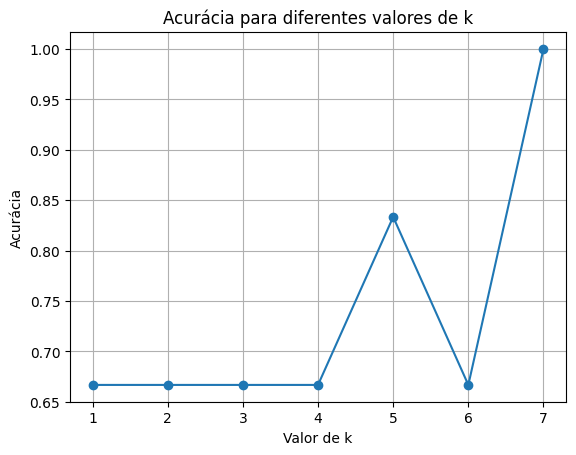

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Testar diferentes valores de k
ks = range(1, 8)  
scores = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"k = {k}, Acurácia = {acc:.2f}")

# Plotar os resultados
plt.plot(ks, scores, marker='o')
plt.xlabel("Valor de k")
plt.ylabel("Acurácia")
plt.title("Acurácia para diferentes valores de k")
plt.grid(True)
plt.show()


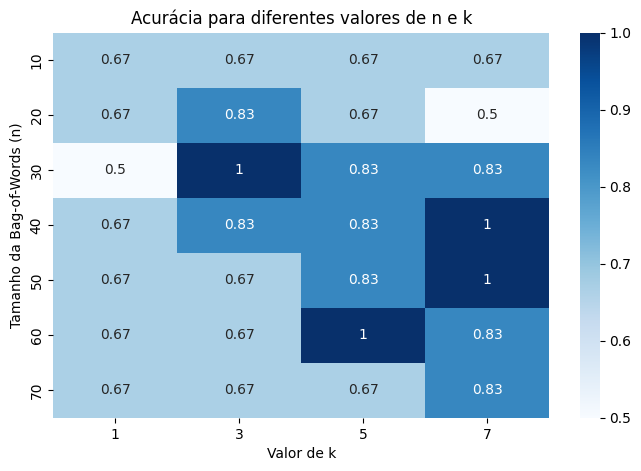

In [9]:
import numpy as np

ns = [10, 20, 30, 40, 50, 60, 70]
ks = [1, 3, 5, 7]
heatmap = np.zeros((len(ns), len(ks)))

for i, n in enumerate(ns):
    # Recriar bag-of-words para cada n
    bag_brasil = termos_mais_frequentes(tokens_brasil, n)
    bag_esporte = termos_mais_frequentes(tokens_esporte, n)
    bag_of_words = list(set(bag_brasil + bag_esporte))
    vocab_index = {termo: i for i, termo in enumerate(bag_of_words)}

    # Regerar vetores binários
    X_train = [vetor_binario(t, vocab_index) for t in tokens_brasil + tokens_esporte]
    X_test = [vetor_binario(t, vocab_index) for t in tokens_test]

    for j, k in enumerate(ks):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        heatmap[i, j] = acc

# Plot do heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap, xticklabels=ks, yticklabels=ns, annot=True, cmap="Blues")
plt.xlabel("Valor de k")
plt.ylabel("Tamanho da Bag-of-Words (n)")
plt.title("Acurácia para diferentes valores de n e k")
plt.show()